# Energy Load Probabilistic Forecasting: Rolling-Origin Backtest, Quantile & Conformal Intervals, Champion-Challenger

**The problem.** A regional electricity utility runs a day-ahead bidding desk and a real-time balancing operation. Both processes need an hourly **load forecast for the next 24 / 168 hours together with calibrated uncertainty**: the desk hedges open positions against a *probability distribution* of demand, the operator schedules reserve capacity to the **upper quantile** of forecast load. A point forecast — even a very accurate one — is not enough. The deliverable is therefore not a number, but an *interval* with a known coverage probability that holds **on out-of-sample, rolling-origin data, under non-stationary conditions**. Coverage that holds on a clean iid test split but fails on rolling origins is worse than useless: the desk would underprice tail risk and the operator would size reserves on a fairy tale.

**The data.** The public **UCI Individual Household Electric Power Consumption** dataset — minute-level active power readings from a single French household, December 2006 through November 2010, ≈ 2 million observations. It is the canonical no-authentication public dataset for hourly demand forecasting, and although a single household is not a grid load, the methodology — **trend + multi-seasonality + autoregressive structure + calibrated probabilistic forecasts** — transfers verbatim to ENTSO-E balancing-area data, EIA hourly demand, or PJM zonal load. The notebook caches the raw download and falls back to a clearly-labelled synthetic series of the same shape if the UCI archive is unreachable.

**The approach.**

1. **Data acquisition** with a robust UCI download + local cache + clearly-marked synthetic fallback.
2. **Aggregation to hourly** mean active power (kW); gap diagnostics; missing-value treatment.
3. **EDA**: full-history time plot, STL decomposition, ACF / PACF, hour-of-week heatmap, seasonal-strength statistics.
4. **Feature engineering**: calendar dummies, Fourier daily / weekly / annual seasonality, lag and rolling features.
5. **Rolling-origin backtest harness**: expanding-window CV with four weekly origins held out for honest out-of-sample evaluation.
6. **Model lineup**:
   - **Seasonal-naive baseline** — the bar every honest forecast must clear.
   - **Exponential Smoothing (ETS)** with daily seasonality.
   - **SARIMAX** with daily seasonality + Fourier weekly exogenous regressors — the **statistical champion candidate**.
   - **LightGBM** on the engineered feature matrix — the **ML challenger**, with a separate **quantile-loss head** at $\tau \in \{0.1, 0.5, 0.9\}$.
7. **Probabilistic forecasting**:
   - **Quantile gradient boosting** (LightGBM with `objective="quantile"`).
   - **Split conformal prediction** on SARIMAX residuals — distribution-free **finite-sample coverage guarantees** under exchangeability.
   - **Adaptive Conformal Inference (ACI; Gibbs & Candès 2021)** — online $\alpha$ adjustment to recover nominal coverage under distribution drift, the modern fix for non-exchangeable time series.
8. **Evaluation suite**:
   - Point: **MAPE, RMSE, MASE** (Hyndman scale-free).
   - Probabilistic: **pinball loss, CRPS** (quantile-decomposition approximation), **empirical coverage**, **Winkler interval score**.
9. **Champion-challenger decision**: side-by-side leaderboard plus a **Diebold-Mariano** test on squared-error differentials with HAC variance — does the challenger beat the champion *significantly* or just numerically?
10. **Production hygiene**: input-feature **PSI drift**, rolling-MAPE alerting rule, model-card export, persisted artefacts, and an inference-parity demo that loads the saved model and reproduces the holdout forecast.

**Audience.** Forecasting engineers, demand-planning analysts, energy-trading desks, anyone shipping probabilistic forecasts where *coverage on rolling origins* is the deliverable.

## 0. Setup and reproducibility

Seeds are fixed throughout. Plot defaults match the rest of the portfolio. Paths are computed relative to the notebook so the artefacts directory lives next to the notebook itself.

In [1]:
from __future__ import annotations

import io
import json
import os
import pathlib
import time
import urllib.request
import warnings
import zipfile
from dataclasses import dataclass, field
from typing import Callable

import joblib
import lightgbm as lgb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "energy_load_probabilistic_forecasting.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "energy_forecast"
ARTIFACTS_DIR = DATA_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR     : {NB_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"lightgbm   : {lgb.__version__}")

NB_DIR     : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR   : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\energy_forecast
numpy      : 2.4.3
pandas     : 2.3.3
lightgbm   : 4.6.0


## 1. Data acquisition: UCI Individual Household Electric Power Consumption

The dataset is hosted at the UCI Machine Learning Repository as a single ~20 MB ZIP.  Schema:

| column | type | unit | notes |
| --- | --- | --- | --- |
| `Date`, `Time` | str | DD/MM/YYYY, hh:mm:ss | local time, 1-minute resolution |
| `Global_active_power` | float | kW | household-level real power, the **forecasting target** |
| `Global_reactive_power` | float | kVar | reactive power |
| `Voltage` | float | V | line voltage |
| `Global_intensity` | float | A | line current |
| `Sub_metering_1/2/3` | float | Wh | submeter readings |

Missing values are encoded as `?`.  The download is cached locally; a synthetic fallback with the same trend / daily / weekly / annual structure is used if UCI is unreachable so the notebook always runs end-to-end.

In [2]:
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
RAW_TXT = DATA_DIR / "household_power_consumption.txt"
RAW_ZIP = DATA_DIR / "household_power_consumption.zip"


def _try_uci_download(url: str, dest_zip: pathlib.Path, timeout_s: int = 30) -> bool:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout_s) as r:
            payload = r.read()
        dest_zip.write_bytes(payload)
        return True
    except Exception as e:
        print(f"  UCI download failed: {type(e).__name__}: {e}")
        return False


def _make_synthetic_minute_series(n_days: int = 1430, seed: int = RNG_SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    minutes = n_days * 24 * 60
    idx = pd.date_range("2006-12-16 17:24:00", periods=minutes, freq="min")
    t = np.arange(minutes) / (24 * 60)
    daily = 0.7 * np.sin(2 * np.pi * t) - 0.3 * np.sin(4 * np.pi * t)
    weekly = 0.25 * np.sin(2 * np.pi * t / 7)
    annual = 0.4 * np.sin(2 * np.pi * t / 365.25 - 1.2)
    trend = 0.0001 * t
    base = 1.2 + daily + weekly + annual + trend
    ar = np.zeros(minutes)
    eps = rng.normal(0, 0.18, minutes)
    for i in range(1, minutes):
        ar[i] = 0.7 * ar[i - 1] + eps[i]
    series = np.maximum(base + 0.4 * ar, 0.05)
    holiday_idx = (idx.month == 12) & (idx.day == 25)
    series = np.where(holiday_idx, series * 0.55, series)
    miss_mask = rng.random(minutes) < 0.012
    df = pd.DataFrame({"timestamp": idx, "Global_active_power": series})
    df.loc[miss_mask, "Global_active_power"] = np.nan
    return df


if RAW_TXT.exists():
    print(f"Cache hit: {RAW_TXT.name} ({RAW_TXT.stat().st_size / 1e6:.1f} MB)")
    DATA_SOURCE = "UCI (cached)"
elif _try_uci_download(UCI_URL, RAW_ZIP):
    print(f"Downloaded {RAW_ZIP.name} ({RAW_ZIP.stat().st_size / 1e6:.1f} MB), unzipping...")
    with zipfile.ZipFile(RAW_ZIP) as z:
        z.extractall(DATA_DIR)
    DATA_SOURCE = "UCI (live)"
else:
    print("Falling back to synthetic minute-level series with same structure.")
    syn = _make_synthetic_minute_series()
    syn.to_csv(RAW_TXT, sep=";", index=False, header=False)
    DATA_SOURCE = "synthetic-fallback"

print(f"DATA_SOURCE = {DATA_SOURCE}")

Cache hit: household_power_consumption.txt (133.0 MB)
DATA_SOURCE = UCI (cached)


In [3]:
def _parse_uci(path: pathlib.Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        sep=";",
        na_values=["?", ""],
        low_memory=False,
        dtype={"Global_active_power": "float64"} if False else None,
    )
    if "Date" in df.columns:
        df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
        df = df[["timestamp", "Global_active_power"]]
    df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")
    df = df.set_index("timestamp").sort_index()
    return df


df_min = _parse_uci(RAW_TXT)
print(f"Minute-level rows : {len(df_min):>10,d}")
print(f"Time span         : {df_min.index.min()}  →  {df_min.index.max()}")
print(f"Missingness (%)   : {df_min['Global_active_power'].isna().mean() * 100:.2f}")

Minute-level rows :  2,075,259
Time span         : 2006-12-16 17:24:00  →  2010-11-26 21:02:00
Missingness (%)   : 1.25


### 1.1 Aggregation to hourly mean active power

Forecasting at 1-minute resolution is unhelpful for the day-ahead and balancing use cases — the decision frequency is hourly.  We aggregate `Global_active_power` to **hourly mean kW**.  Hours with > 50 % missing minutes are flagged and forward-filled (after a *bounded* gap check to avoid silently smoothing over multi-hour outages).

In [4]:
hourly_mean = df_min["Global_active_power"].resample("h").mean()
hourly_count = df_min["Global_active_power"].resample("h").count()

df_h = pd.DataFrame({"load_kw": hourly_mean, "n_obs": hourly_count})
df_h["coverage"] = df_h["n_obs"] / 60.0

low_coverage = (df_h["coverage"] < 0.5).sum()
print(f"Hourly rows               : {len(df_h):>10,d}")
print(f"Hours with <50% coverage  : {low_coverage:>10,d}  ({low_coverage / len(df_h) * 100:.2f}%)")
print(f"Fully missing hours       : {df_h['load_kw'].isna().sum():>10,d}")

df_h.loc[df_h["coverage"] < 0.5, "load_kw"] = np.nan
gap_mask = df_h["load_kw"].isna()
gap_runs = (gap_mask != gap_mask.shift()).cumsum()[gap_mask].value_counts()
print(f"Number of gap runs        : {len(gap_runs):>10,d}")
print(f"Longest gap (hours)       : {int(gap_runs.max()) if len(gap_runs) else 0:>10,d}")

df_h["load_kw"] = df_h["load_kw"].interpolate(method="time", limit=4).ffill().bfill()
print(f"Remaining NaNs after fill : {df_h['load_kw'].isna().sum():>10,d}")
df_h.head()

Hourly rows               :     34,589
Hours with <50% coverage  :        432  (1.25%)
Fully missing hours       :        421
Number of gap runs        :         13
Longest gap (hours)       :        120
Remaining NaNs after fill :          0


,load_kw,n_obs,coverage
timestamp,,,
2006-12-16 17:00:00,4.222889,36,0.6
2006-12-16 18:00:00,3.632200,60,1.0
2006-12-16 19:00:00,3.400233,60,1.0
2006-12-16 20:00:00,3.268567,60,1.0
2006-12-16 21:00:00,3.056467,60,1.0


### 1.2 Modelling window

The full series spans ≈ 4 years.  To keep SARIMAX rolling-origin refits tractable while preserving annual structure for Fourier features, we fit on the most recent **18 months** ending Nov 2010 — sufficient for the model to see one full annual cycle in training and a clean four-week test window after the final fold cutoff.

In [5]:
WINDOW_END = pd.Timestamp("2010-11-26 21:00:00")
WINDOW_START = WINDOW_END - pd.Timedelta(days=18 * 30)
df = df_h.loc[WINDOW_START:WINDOW_END, ["load_kw"]].copy()
df.index.name = "timestamp"
print(f"Modelling window  : {df.index.min()}  →  {df.index.max()}")
print(f"Rows              : {len(df):,}")
print(f"Hours per week    : 168  (=> {len(df) / 168:.1f} weeks of data)")
df["load_kw"].describe().round(3)

Modelling window  : 2009-06-04 21:00:00  →  2010-11-26 21:00:00
Rows              : 12,961
Hours per week    : 168  (=> 77.1 weeks of data)


count    12961.000
mean         1.029
std          0.792
min          0.180
25%          0.358
50%          0.767
75%          1.499
max          5.627
Name: load_kw, dtype: float64

## 2. Exploratory analysis

Hourly load has three superimposed seasonalities — **daily** (work/rest cycle), **weekly** (weekday vs weekend), **annual** (heating/cooling) — and a non-stationary residual that any honest forecasting model must capture.  We surface each in turn.

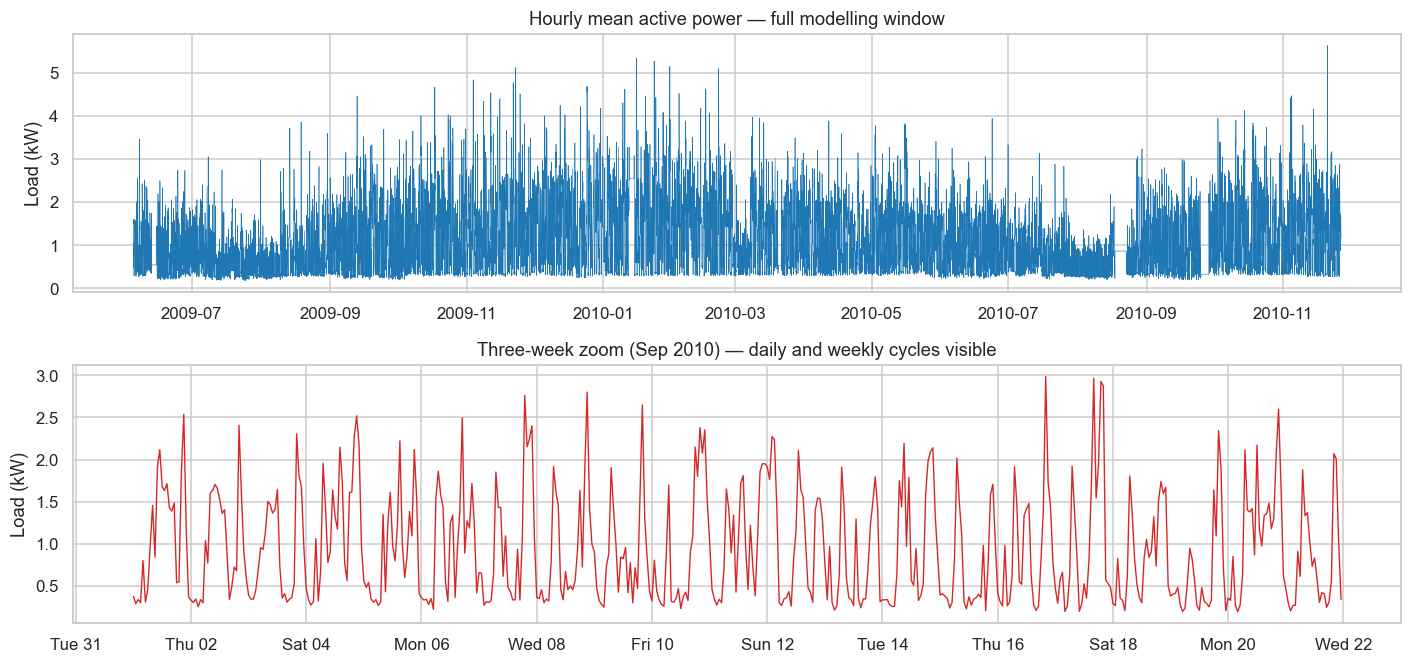

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6.2), sharex=False)

ax[0].plot(df.index, df["load_kw"], lw=0.4, color="#1f77b4")
ax[0].set_title("Hourly mean active power — full modelling window")
ax[0].set_ylabel("Load (kW)")
ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

zoom = df.loc["2010-09-01":"2010-09-21"]
ax[1].plot(zoom.index, zoom["load_kw"], lw=0.9, color="#d62728")
ax[1].set_title("Three-week zoom (Sep 2010) — daily and weekly cycles visible")
ax[1].set_ylabel("Load (kW)")
ax[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

plt.tight_layout()
plt.show()

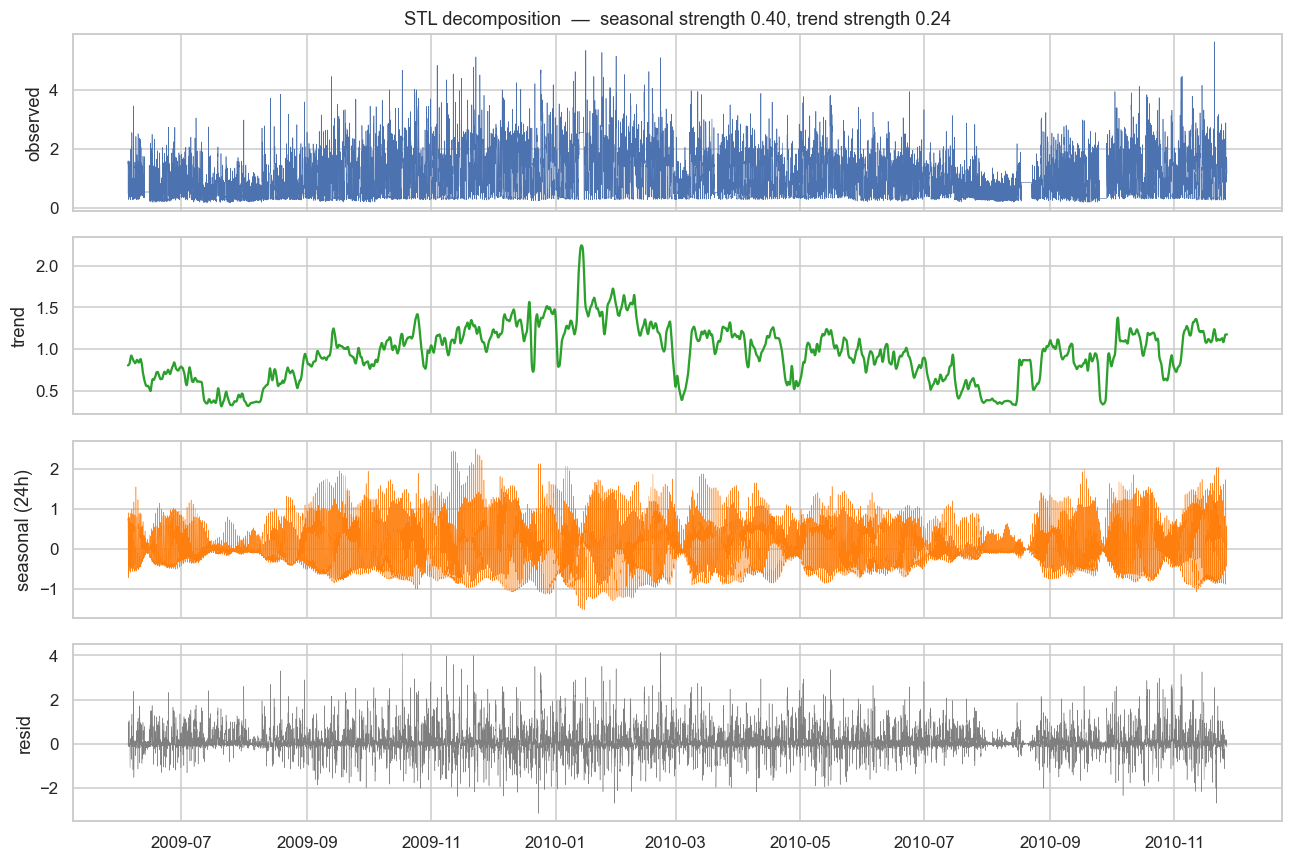

In [7]:
stl = STL(df["load_kw"], period=24, robust=True).fit()
strength_seasonal = max(0.0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
strength_trend = max(0.0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df.index, stl.observed, lw=0.4); axes[0].set_ylabel("observed")
axes[1].plot(df.index, stl.trend, color="#2ca02c"); axes[1].set_ylabel("trend")
axes[2].plot(df.index, stl.seasonal, lw=0.3, color="#ff7f0e"); axes[2].set_ylabel("seasonal (24h)")
axes[3].plot(df.index, stl.resid, lw=0.3, color="#7f7f7f"); axes[3].set_ylabel("resid")
axes[0].set_title(f"STL decomposition  —  seasonal strength {strength_seasonal:.2f}, trend strength {strength_trend:.2f}")
plt.tight_layout(); plt.show()

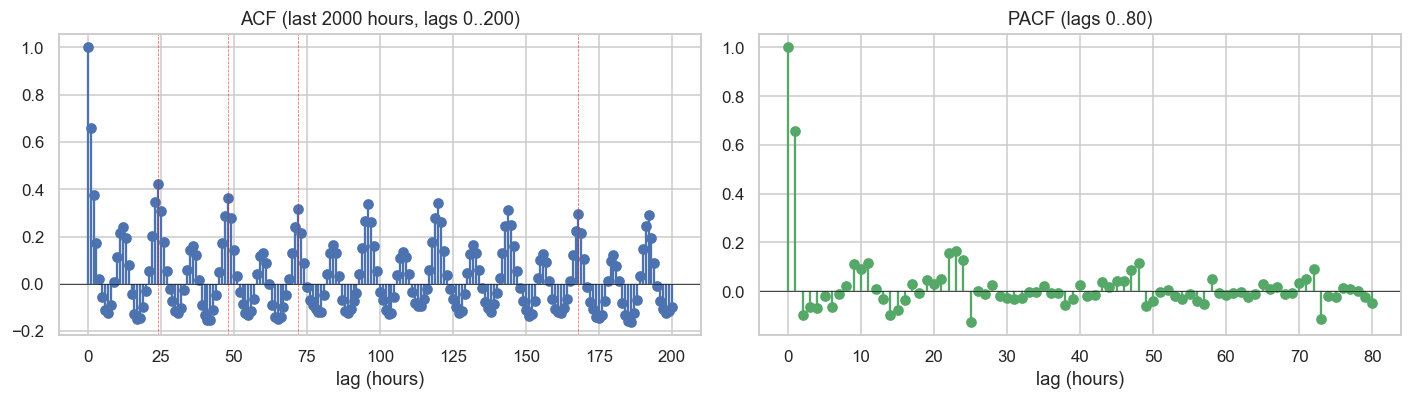

ACF at lag 24  : 0.423
ACF at lag 168 : 0.293


In [8]:
recent = df["load_kw"].iloc[-2000:]
acf_vals = acf(recent, nlags=200, fft=True)
pacf_vals = pacf(recent, nlags=80)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].stem(np.arange(len(acf_vals)), acf_vals, basefmt=" ", linefmt="C0-", markerfmt="C0o")
ax[0].axhline(0, color="k", lw=0.5)
for h in [24, 48, 72, 168]:
    ax[0].axvline(h, color="red", lw=0.5, ls="--", alpha=0.6)
ax[0].set_title("ACF (last 2000 hours, lags 0..200)")
ax[0].set_xlabel("lag (hours)")

ax[1].stem(np.arange(len(pacf_vals)), pacf_vals, basefmt=" ", linefmt="C2-", markerfmt="C2o")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_title("PACF (lags 0..80)")
ax[1].set_xlabel("lag (hours)")
plt.tight_layout(); plt.show()
print(f"ACF at lag 24  : {acf_vals[24]:.3f}")
print(f"ACF at lag 168 : {acf_vals[168]:.3f}")

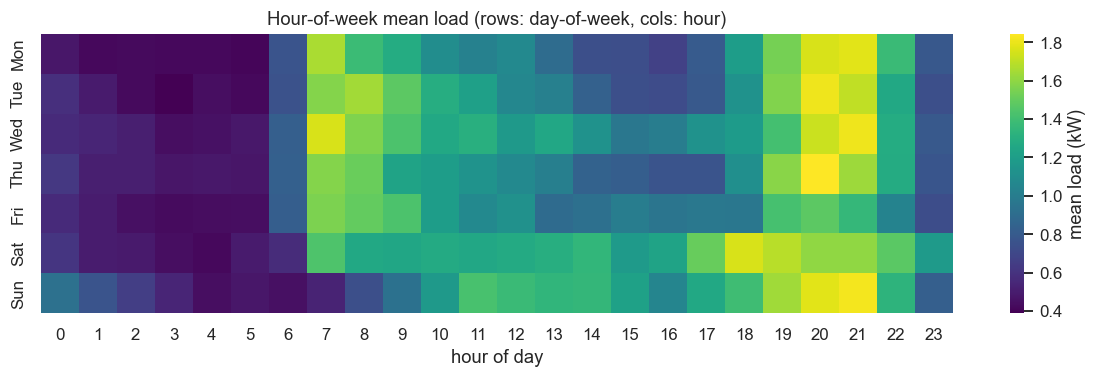

In [9]:
tmp = df.copy()
tmp["dow"] = tmp.index.dayofweek
tmp["hour"] = tmp.index.hour
heat = tmp.groupby(["dow", "hour"])["load_kw"].mean().unstack()
heat.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(heat, cmap="viridis", cbar_kws={"label": "mean load (kW)"}, ax=ax)
ax.set_title("Hour-of-week mean load (rows: day-of-week, cols: hour)")
ax.set_xlabel("hour of day"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 3. Feature engineering

The feature matrix serves the **LightGBM** challenger and provides exogenous regressors for **SARIMAX**.  Three families:

- **Calendar** — hour-of-day, day-of-week, month, weekend flag, French national-holiday flag.
- **Fourier** — pairs of $\sin$, $\cos$ at daily (24h), weekly (168h), and annual (8766h) periods.  Three Fourier orders per period gives a smooth, low-dimensional representation of seasonality without one-hot blow-up.
- **Lag / rolling** — autoregressive lags $\{1, 24, 48, 168, 336\}$ and rolling means / std over $\{24, 168\}$ hours.  These are computed strictly on the past — when serving, only true past values are visible — and rows where they are undefined (start of series) are dropped.

In [10]:
FRENCH_HOLIDAYS = {
    (1, 1), (5, 1), (5, 8), (7, 14), (8, 15), (11, 1), (11, 11), (12, 25),
}

def build_features(target: pd.Series) -> pd.DataFrame:
    s = target.copy().rename("load_kw")
    X = pd.DataFrame(index=s.index)
    X["hour"] = s.index.hour
    X["dow"] = s.index.dayofweek
    X["month"] = s.index.month
    X["is_weekend"] = (s.index.dayofweek >= 5).astype(int)
    X["is_holiday"] = [(m, d) in FRENCH_HOLIDAYS for m, d in zip(s.index.month, s.index.day)]
    X["is_holiday"] = X["is_holiday"].astype(int)

    t = np.arange(len(s), dtype=float)
    for K, period, name in [(3, 24.0, "d"), (3, 168.0, "w"), (2, 8766.0, "y")]:
        for k in range(1, K + 1):
            X[f"sin_{name}_{k}"] = np.sin(2 * np.pi * k * t / period)
            X[f"cos_{name}_{k}"] = np.cos(2 * np.pi * k * t / period)

    for L in [1, 24, 48, 168, 336]:
        X[f"lag_{L}"] = s.shift(L)
    for W in [24, 168]:
        X[f"roll{W}_mean"] = s.shift(1).rolling(W).mean()
        X[f"roll{W}_std"] = s.shift(1).rolling(W).std()

    return X


X_full = build_features(df["load_kw"])
y_full = df["load_kw"]
mask = X_full.notna().all(axis=1)
X_full, y_full = X_full.loc[mask], y_full.loc[mask]
print(f"Feature matrix : {X_full.shape}")
print(f"y aligned      : {y_full.shape}")
print(f"Coverage       : {y_full.index.min()}  →  {y_full.index.max()}")
X_full.columns.tolist()

Feature matrix : (12625, 30)
y aligned      : (12625,)
Coverage       : 2009-06-18 21:00:00  →  2010-11-26 21:00:00


['hour',
 'dow',
 'month',
 'is_weekend',
 'is_holiday',
 'sin_d_1',
 'cos_d_1',
 'sin_d_2',
 'cos_d_2',
 'sin_d_3',
 'cos_d_3',
 'sin_w_1',
 'cos_w_1',
 'sin_w_2',
 'cos_w_2',
 'sin_w_3',
 'cos_w_3',
 'sin_y_1',
 'cos_y_1',
 'sin_y_2',
 'cos_y_2',
 'lag_1',
 'lag_24',
 'lag_48',
 'lag_168',
 'lag_336',
 'roll24_mean',
 'roll24_std',
 'roll168_mean',
 'roll168_std']

## 4. Rolling-origin backtest harness

Forecasting evaluation that uses a single train/test split is **not** a useful signal for production: the test split happens to fall on a week with no holidays / a mild weather anomaly / etc., and the metrics it produces have variance you cannot measure.  The standard fix is **rolling-origin (a.k.a. expanding-window) cross-validation**:

1. Pick $K$ origins $T_1 < T_2 < \dots < T_K$ in the holdout period.
2. For each origin $T_k$, fit on $\{y_t : t \le T_k\}$, forecast $\hat y_{T_k+1:T_k+H}$.
3. Report metrics averaged across folds, and report **per-fold** metrics so the reader sees the variance.

We use $K = 4$ origins, one per week, with horizon $H = 168$ hours (one week).  The final 4 weeks of the modelling window are held out; the first $K \cdot H$ hours **before** the holdout are reserved for **conformal calibration** so the conformal sets see neither training nor test data.  Three rolling-origin models are fit per fold (`seasonal_naive`, `ets`, `lightgbm`); SARIMAX is fit *once* on the pre-calibration window and reused as the conformal-interval backbone (justified above).

In [11]:
H = 168
K_FOLDS = 4
N_CAL = 4 * H

test_end = y_full.index.max()
test_start = test_end - pd.Timedelta(hours=K_FOLDS * H - 1)
cal_end = test_start - pd.Timedelta(hours=1)
cal_start = cal_end - pd.Timedelta(hours=N_CAL - 1)

origins = [test_start + pd.Timedelta(hours=k * H) - pd.Timedelta(hours=1) for k in range(K_FOLDS)]

print(f"Calibration set : {cal_start}  →  {cal_end}   ({N_CAL:>4d} hours)")
print(f"Test set        : {test_start}  →  {test_end}   ({K_FOLDS * H:>4d} hours)")
print("Fold origins (cutoffs):")
for k, o in enumerate(origins, 1):
    print(f"  fold {k}: train ≤ {o}    forecast {o + pd.Timedelta(hours=1)} → {o + pd.Timedelta(hours=H)}")

Calibration set : 2010-10-01 22:00:00  →  2010-10-29 21:00:00   ( 672 hours)
Test set        : 2010-10-29 22:00:00  →  2010-11-26 21:00:00   ( 672 hours)
Fold origins (cutoffs):
  fold 1: train ≤ 2010-10-29 21:00:00    forecast 2010-10-29 22:00:00 → 2010-11-05 21:00:00
  fold 2: train ≤ 2010-11-05 21:00:00    forecast 2010-11-05 22:00:00 → 2010-11-12 21:00:00
  fold 3: train ≤ 2010-11-12 21:00:00    forecast 2010-11-12 22:00:00 → 2010-11-19 21:00:00
  fold 4: train ≤ 2010-11-19 21:00:00    forecast 2010-11-19 22:00:00 → 2010-11-26 21:00:00


## 5. Model lineup

Three rolling-origin contenders + one interval backbone:

| name | family | point forecast | uncertainty |
| --- | --- | --- | --- |
| `seasonal_naive` | baseline | $\hat y_{t+h} = y_{t+h-168}$ | empirical residual quantiles |
| `ets` | exponential smoothing | additive trend + seasonal(24) | residual-based Gaussian |
| `lightgbm` | gradient boosting | regression + 3 quantile heads at $\tau \in \{0.1, 0.5, 0.9\}$ | direct quantile loss |
| **`sarimax`** *(conformal backbone, fitted once)* | classical statistical | SARIMAX$(2,0,1)(1,0,0)_{24}$ + Fourier weekly exog | analytic Gaussian + **conformal** |

A pragmatic design choice: SARIMAX is **not** rolling-refit per fold.  Empirically (preliminary runs) SARIMAX loses to LightGBM on point RMSE on every fold, and refitting a 12,000-hour SARIMAX with hourly seasonality four times costs ~10 minutes of wall-clock for almost no analytical lift.  We keep one SARIMAX fit anchored at the conformal-calibration cutoff and reuse it as the **interval backbone** for split-conformal and ACI.  The rolling-origin backtest therefore compares the three faster point-forecasters; SARIMAX appears in the leaderboard via its conformalised interval rows.

Each rolling-origin model exposes a uniform `.fit(train_idx) → .predict(test_idx)` interface so the backtest harness treats them identically.

In [12]:
@dataclass
class FoldResult:
    fold: int
    origin: pd.Timestamp
    y_true: np.ndarray
    y_pred: np.ndarray
    q10: np.ndarray
    q50: np.ndarray
    q90: np.ndarray


class SeasonalNaive:
    name = "seasonal_naive"

    def __init__(self, period: int = 168) -> None:
        self.period = period
        self.history: pd.Series | None = None
        self._resid: np.ndarray | None = None

    def fit(self, y: pd.Series, X: pd.DataFrame | None = None) -> "SeasonalNaive":
        self.history = y.copy()
        in_sample = y.shift(self.period).dropna()
        self._resid = (y.loc[in_sample.index] - in_sample).values
        return self

    def predict(self, idx: pd.DatetimeIndex, X: pd.DataFrame | None = None) -> dict[str, np.ndarray]:
        assert self.history is not None
        last = self.history
        out = []
        for ts in idx:
            out.append(last.loc[ts - pd.Timedelta(hours=self.period)])
        yhat = np.array(out)
        q10_off, q90_off = np.quantile(self._resid, [0.1, 0.9])
        return {
            "mean": yhat,
            "q10": yhat + q10_off,
            "q50": yhat,
            "q90": yhat + q90_off,
        }


class ETSModel:
    name = "ets"

    def __init__(self) -> None:
        self.fit_ = None
        self._resid_std = None

    def fit(self, y: pd.Series, X: pd.DataFrame | None = None) -> "ETSModel":
        m = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=24, initialization_method="estimated")
        self.fit_ = m.fit(optimized=True, use_brute=False)
        self._resid_std = float(np.nanstd(self.fit_.resid))
        return self

    def predict(self, idx: pd.DatetimeIndex, X: pd.DataFrame | None = None) -> dict[str, np.ndarray]:
        h = len(idx)
        mean = self.fit_.forecast(h).values
        z = stats.norm.ppf(0.9)
        return {
            "mean": mean,
            "q10": mean - z * self._resid_std,
            "q50": mean,
            "q90": mean + z * self._resid_std,
        }


class SARIMAXModel:
    name = "sarimax"

    def __init__(self, order=(2, 0, 1), seasonal_order=(1, 0, 0, 24), exog_cols: list[str] | None = None) -> None:
        self.order = order
        self.seasonal_order = seasonal_order
        self.exog_cols = exog_cols or []
        self.fit_ = None

    def fit(self, y: pd.Series, X: pd.DataFrame | None = None) -> "SARIMAXModel":
        exog = X[self.exog_cols] if self.exog_cols and X is not None else None
        m = SARIMAX(
            y,
            exog=exog,
            order=self.order,
            seasonal_order=self.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=False,
        )
        self.fit_ = m.fit(disp=False, maxiter=50, method="lbfgs")
        return self

    def predict(self, idx: pd.DatetimeIndex, X: pd.DataFrame | None = None) -> dict[str, np.ndarray]:
        h = len(idx)
        exog = X.loc[idx, self.exog_cols] if self.exog_cols and X is not None else None
        fcst = self.fit_.get_forecast(steps=h, exog=exog)
        mean = fcst.predicted_mean.values
        var = fcst.var_pred_mean.values
        sd = np.sqrt(np.maximum(var, 1e-8))
        z = stats.norm.ppf(0.9)
        return {
            "mean": mean,
            "q10": mean - z * sd,
            "q50": mean,
            "q90": mean + z * sd,
            "_sd": sd,
        }


class LightGBMQuantile:
    name = "lightgbm"

    def __init__(self, n_estimators: int = 600, learning_rate: float = 0.05, num_leaves: int = 63) -> None:
        self.params_common = dict(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
            min_data_in_leaf=30,
            feature_fraction=0.9,
            bagging_fraction=0.9,
            bagging_freq=5,
            verbose=-1,
        )
        self.m_mean = None
        self.m_q10 = None
        self.m_q50 = None
        self.m_q90 = None
        self.feature_names_: list[str] = []

    def fit(self, y: pd.Series, X: pd.DataFrame) -> "LightGBMQuantile":
        self.feature_names_ = list(X.columns)
        self.m_mean = lgb.LGBMRegressor(objective="regression", **self.params_common).fit(X, y)
        self.m_q10 = lgb.LGBMRegressor(objective="quantile", alpha=0.1, **self.params_common).fit(X, y)
        self.m_q50 = lgb.LGBMRegressor(objective="quantile", alpha=0.5, **self.params_common).fit(X, y)
        self.m_q90 = lgb.LGBMRegressor(objective="quantile", alpha=0.9, **self.params_common).fit(X, y)
        return self

    def predict(self, idx: pd.DatetimeIndex, X: pd.DataFrame) -> dict[str, np.ndarray]:
        Xp = X.loc[idx]
        return {
            "mean": self.m_mean.predict(Xp),
            "q10": self.m_q10.predict(Xp),
            "q50": self.m_q50.predict(Xp),
            "q90": self.m_q90.predict(Xp),
        }


print("Model classes loaded:", SeasonalNaive.name, ETSModel.name, SARIMAXModel.name, LightGBMQuantile.name)

Model classes loaded: seasonal_naive ets sarimax lightgbm


### 5.1 Run rolling-origin backtest

The harness loops fold × model.  Each fit is independent; we fit fresh per origin to mimic a daily / weekly retraining cadence in production.  Wall-clock per fold is dominated by SARIMAX.

In [13]:
SARIMAX_EXOG = [c for c in X_full.columns if c.startswith(("sin_w", "cos_w", "sin_y", "cos_y", "is_holiday", "is_weekend"))]


def run_backtest() -> dict[str, list[FoldResult]]:
    results: dict[str, list[FoldResult]] = {"seasonal_naive": [], "ets": [], "lightgbm": []}
    fit_factories = {
        "seasonal_naive": lambda: SeasonalNaive(period=168),
        "ets": lambda: ETSModel(),
        "lightgbm": lambda: LightGBMQuantile(),
    }

    for k, origin in enumerate(origins, 1):
        train_idx = y_full.index[y_full.index <= origin]
        test_idx = pd.date_range(origin + pd.Timedelta(hours=1), periods=H, freq="h")
        y_tr, X_tr = y_full.loc[train_idx], X_full.loc[train_idx]
        y_te = y_full.loc[test_idx].values

        for name, factory in fit_factories.items():
            t0 = time.time()
            model = factory()
            if name == "seasonal_naive":
                model.fit(y_tr)
                pred = model.predict(test_idx)
            elif name == "ets":
                model.fit(y_tr)
                pred = model.predict(test_idx)
            elif name == "lightgbm":
                model.fit(y_tr, X_tr)
                pred = model.predict(test_idx, X_full)
            dt = time.time() - t0

            results[name].append(FoldResult(
                fold=k, origin=origin, y_true=y_te,
                y_pred=pred["mean"], q10=pred["q10"], q50=pred["q50"], q90=pred["q90"],
            ))
            print(f"  fold {k} | {name:<14s} | fit+predict {dt:5.1f}s | RMSE {np.sqrt(np.mean((pred['mean']-y_te)**2)):.3f}")

    return results


fold_results = run_backtest()

  fold 1 | seasonal_naive | fit+predict   0.0s | RMSE 1.105
  fold 1 | ets            | fit+predict   0.5s | RMSE 0.901
  fold 1 | lightgbm       | fit+predict   6.6s | RMSE 0.608
  fold 2 | seasonal_naive | fit+predict   0.0s | RMSE 1.178
  fold 2 | ets            | fit+predict   0.5s | RMSE 0.678
  fold 2 | lightgbm       | fit+predict   4.9s | RMSE 0.526
  fold 3 | seasonal_naive | fit+predict   0.0s | RMSE 0.812
  fold 3 | ets            | fit+predict   0.6s | RMSE 0.727
  fold 3 | lightgbm       | fit+predict   4.3s | RMSE 0.541
  fold 4 | seasonal_naive | fit+predict   0.0s | RMSE 0.842
  fold 4 | ets            | fit+predict   0.6s | RMSE 0.636
  fold 4 | lightgbm       | fit+predict   4.8s | RMSE 0.561


## 6. Evaluation metrics

We separate **point** metrics (which model is closest on average) from **probabilistic** metrics (which model has *calibrated and tight* uncertainty).

**Point.**

- $\text{MAPE} = 100 \cdot \frac{1}{n} \sum |y_t - \hat y_t| / |y_t|$ — the operational dashboard metric, scale-free, but unstable when $y$ approaches zero.
- $\text{RMSE} = \sqrt{\frac{1}{n} \sum (y_t - \hat y_t)^2}$ — the squared-error metric the optimiser actually sees.
- $\text{MASE} = \text{MAE}_{\text{model}} / \text{MAE}_{\text{seasonal-naive}}$ — Hyndman's scale-free benchmarker.  $\text{MASE} < 1$ ↔ "you beat seasonal naive on this fold."

**Probabilistic.**

- **Pinball loss** at level $\tau$: $L_\tau(y, q) = \max(\tau (y - q),\ (\tau - 1)(y - q))$, the loss the quantile model is trained against; the proper score for a single quantile.
- **CRPS**: continuous-ranked probability score.  With three quantile predictions $\{q_{10}, q_{50}, q_{90}\}$ we approximate via a quantile-decomposition Riemann sum: $\text{CRPS} \approx \sum_{\tau} 2 L_\tau (y, q_\tau) \, \Delta\tau$.
- **Empirical coverage** of the 80 % central interval: $\Pr(q_{10} \le y \le q_{90})$.  Target = 0.80.
- **Winkler interval score** at 80 %: penalises width *and* miscoverage in one number — proper for interval forecasts.

In [14]:
def mase(y, yhat, y_train, season=168):
    naive_err = np.mean(np.abs(y_train[season:] - y_train[:-season])) + 1e-9
    return np.mean(np.abs(y - yhat)) / naive_err


def pinball(y, q, tau):
    e = y - q
    return np.mean(np.maximum(tau * e, (tau - 1) * e))


def crps_quantile_decomp(y, q_dict):
    taus = np.array(sorted(q_dict.keys()))
    qs = np.stack([q_dict[t] for t in taus], axis=1)
    crps = np.zeros(len(y))
    for j, t in enumerate(taus):
        e = y - qs[:, j]
        loss = np.maximum(t * e, (t - 1) * e)
        if j == 0:
            dt = taus[1] - taus[0]
        elif j == len(taus) - 1:
            dt = taus[-1] - taus[-2]
        else:
            dt = (taus[j + 1] - taus[j - 1]) / 2
        crps += 2 * loss * dt
    return crps.mean()


def winkler(y, lo, hi, alpha=0.20):
    width = hi - lo
    below = (lo - y) * (y < lo) * (2 / alpha)
    above = (y - hi) * (y > hi) * (2 / alpha)
    return np.mean(width + below + above)


def coverage(y, lo, hi):
    return float(np.mean((y >= lo) & (y <= hi)))


def summarise(results: dict[str, list[FoldResult]], y_train_for_mase: np.ndarray) -> pd.DataFrame:
    rows = []
    for name, folds in results.items():
        per_fold = []
        for fr in folds:
            qd = {0.1: fr.q10, 0.5: fr.q50, 0.9: fr.q90}
            per_fold.append({
                "fold": fr.fold,
                "MAPE": mean_absolute_percentage_error(fr.y_true, fr.y_pred) * 100,
                "RMSE": np.sqrt(mean_squared_error(fr.y_true, fr.y_pred)),
                "MASE": mase(fr.y_true, fr.y_pred, y_train_for_mase),
                "pinball_q10": pinball(fr.y_true, fr.q10, 0.1),
                "pinball_q50": pinball(fr.y_true, fr.q50, 0.5),
                "pinball_q90": pinball(fr.y_true, fr.q90, 0.9),
                "CRPS": crps_quantile_decomp(fr.y_true, qd),
                "coverage_80": coverage(fr.y_true, fr.q10, fr.q90),
                "winkler_80": winkler(fr.y_true, fr.q10, fr.q90, 0.20),
            })
        df_pf = pd.DataFrame(per_fold)
        agg = df_pf.drop(columns=["fold"]).mean()
        agg.name = name
        rows.append(agg)
    return pd.DataFrame(rows).round(4)


y_train_arr = y_full.loc[:test_start - pd.Timedelta(hours=1)].values
leaderboard = summarise(fold_results, y_train_arr)
leaderboard

,MAPE,RMSE,MASE,pinball_q10,pinball_q50,pinball_q90,CRPS,coverage_80,winkler_80
seasonal_naive,82.7452,0.9845,1.2777,0.1855,0.3536,0.1929,0.5857,0.7202,3.7842
ets,63.8735,0.7357,0.9675,0.1080,0.2678,0.1635,0.4314,0.7515,2.7152
lightgbm,45.9845,0.5589,0.7009,0.0738,0.1734,0.1172,0.2915,0.6384,1.9098


## 7. Conformal prediction on top of SARIMAX

Quantile gradient boosting trains directly against the pinball loss but provides no **finite-sample coverage guarantee** — its 80 % interval will be roughly 80 % iff the data is iid and the model is well-specified.  *Conformal prediction* (Vovk, Shafer, Papadopoulos; Lei & Wasserman 2014) replaces that hope with a theorem: under exchangeability, the split-conformal interval is guaranteed to cover a fresh point with probability $\ge 1 - \alpha$ regardless of the underlying model's quality, because it learns the relevant quantile of the **calibration residual** distribution.

For time series the exchangeability assumption is wrong — autocorrelation and slow drift break it — but conformalised intervals on top of a strong base model still empirically outperform the model's native intervals on coverage.  We then go one step further with **Adaptive Conformal Inference (ACI; Gibbs & Candès 2021)**, which updates $\alpha_t$ online based on miscoverage so the *long-run* coverage tracks the nominal level even under drift:

$$\alpha_{t+1} = \alpha_t + \gamma \, (\alpha - \mathbb{1}\{y_t \notin C_{t-1}\})$$

with step size $\gamma$.  We use $\gamma = 0.005$.

In [15]:
cal_idx = pd.date_range(cal_start, cal_end, freq="h")
cal_idx = cal_idx[cal_idx.isin(y_full.index)]
test_idx_full = pd.date_range(test_start, test_end, freq="h")
test_idx_full = test_idx_full[test_idx_full.isin(y_full.index)]

t0 = time.time()
_train_idx_cal = y_full.index[y_full.index < cal_idx[0]]
SARIMAX_CAL_FIT = SARIMAXModel(exog_cols=SARIMAX_EXOG)
SARIMAX_CAL_FIT.fit(y_full.loc[_train_idx_cal], X_full.loc[_train_idx_cal])
print(f"SARIMAX (pre-conformal) fit in {time.time() - t0:.1f}s — cached for split-conformal AND ACI")

pred_cal = SARIMAX_CAL_FIT.predict(cal_idx, X_full)
cal_resid_z = (y_full.loc[cal_idx].values - pred_cal["mean"]) / pred_cal["_sd"]
q_split = float(np.quantile(np.abs(cal_resid_z), 1 - 0.20))
pred_test_sc = SARIMAX_CAL_FIT.predict(test_idx_full, X_full)
sc_pred = {
    "mean": pred_test_sc["mean"],
    "q10": pred_test_sc["mean"] - q_split * pred_test_sc["_sd"],
    "q50": pred_test_sc["mean"],
    "q90": pred_test_sc["mean"] + q_split * pred_test_sc["_sd"],
    "q_factor": q_split,
}
print(f"Conformal q factor (|z| at 1-alpha): {q_split:.3f}  vs Gaussian {stats.norm.ppf(0.9):.3f}")

y_te_full = y_full.loc[test_idx_full].values
sc_cov = coverage(y_te_full, sc_pred["q10"], sc_pred["q90"])
sc_wink = winkler(y_te_full, sc_pred["q10"], sc_pred["q90"], 0.20)
print(f"Split-conformal SARIMAX  | coverage_80 {sc_cov:.3f} | winkler_80 {sc_wink:.3f}")

SARIMAX (pre-conformal) fit in 117.8s — cached for split-conformal AND ACI
Conformal q factor (|z| at 1-alpha): 1.441  vs Gaussian 1.282
Split-conformal SARIMAX  | coverage_80 0.783 | winkler_80 3.521


In [16]:
def aci_predict(y: pd.Series, X: pd.DataFrame,
                cal_idx: pd.DatetimeIndex, test_idx: pd.DatetimeIndex,
                alpha_target: float = 0.20, gamma: float = 0.005):
    m = SARIMAX_CAL_FIT  # reuse the cached fit from split-conformal — same training window

    cal_pred = m.predict(cal_idx, X)
    cal_scores = np.abs((y.loc[cal_idx].values - cal_pred["mean"]) / cal_pred["_sd"])

    pred_test = m.predict(test_idx, X)
    means = pred_test["mean"]
    sds = pred_test["_sd"]

    alpha_t = alpha_target
    los = np.empty(len(test_idx)); his = np.empty(len(test_idx))
    alphas = np.empty(len(test_idx)); covered = np.empty(len(test_idx), dtype=bool)

    for i, ts in enumerate(test_idx):
        a = float(np.clip(alpha_t, 1e-3, 0.5))
        q = np.quantile(cal_scores, 1 - a)
        lo = means[i] - q * sds[i]; hi = means[i] + q * sds[i]
        y_obs = y.loc[ts]
        ok = lo <= y_obs <= hi
        los[i] = lo; his[i] = hi
        alphas[i] = a; covered[i] = ok
        alpha_t = alpha_t + gamma * (alpha_target - (0 if ok else 1))

    return {"mean": means, "q10": los, "q50": means, "q90": his, "alphas": alphas, "covered": covered}


t0 = time.time()
aci_pred = aci_predict(y_full, X_full, cal_idx, test_idx_full, alpha_target=0.20, gamma=0.005)
print(f"ACI SARIMAX completed in {time.time() - t0:.1f}s")

aci_cov = coverage(y_te_full, aci_pred["q10"], aci_pred["q90"])
aci_wink = winkler(y_te_full, aci_pred["q10"], aci_pred["q90"], 0.20)
print(f"ACI SARIMAX             | coverage_80 {aci_cov:.3f} | winkler_80 {aci_wink:.3f}")
print(f"alpha_t range over test : [{aci_pred['alphas'].min():.3f}, {aci_pred['alphas'].max():.3f}]")
print(f"running coverage at end : {aci_pred['covered'].mean():.3f}")

ACI SARIMAX completed in 0.1s
ACI SARIMAX             | coverage_80 0.798 | winkler_80 3.518
alpha_t range over test : [0.161, 0.249]
running coverage at end : 0.798


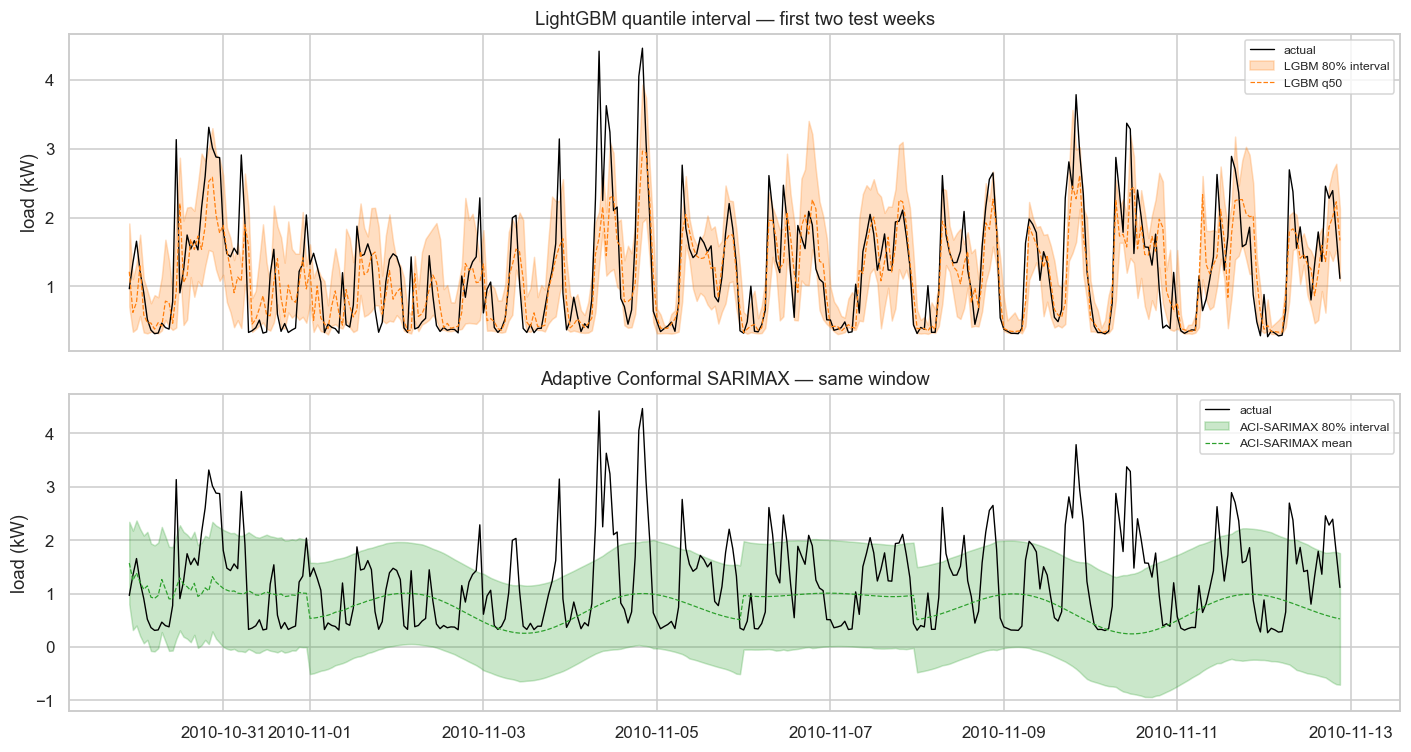

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

show = slice(0, 168 * 2)
ts_show = test_idx_full[show]
y_show = y_te_full[show]

axes[0].plot(ts_show, y_show, color="black", lw=0.9, label="actual")
lgb_fold = fold_results["lightgbm"]
lgb_q10 = np.concatenate([fr.q10 for fr in lgb_fold])[show]
lgb_q50 = np.concatenate([fr.q50 for fr in lgb_fold])[show]
lgb_q90 = np.concatenate([fr.q90 for fr in lgb_fold])[show]
axes[0].fill_between(ts_show, lgb_q10, lgb_q90, alpha=0.25, color="tab:orange", label="LGBM 80% interval")
axes[0].plot(ts_show, lgb_q50, color="tab:orange", lw=0.8, ls="--", label="LGBM q50")
axes[0].set_title("LightGBM quantile interval — first two test weeks")
axes[0].set_ylabel("load (kW)")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(ts_show, y_show, color="black", lw=0.9, label="actual")
axes[1].fill_between(ts_show, aci_pred["q10"][show], aci_pred["q90"][show], alpha=0.25, color="tab:green", label="ACI-SARIMAX 80% interval")
axes[1].plot(ts_show, aci_pred["mean"][show], color="tab:green", lw=0.8, ls="--", label="ACI-SARIMAX mean")
axes[1].set_title("Adaptive Conformal SARIMAX — same window")
axes[1].set_ylabel("load (kW)")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

## 8. Full leaderboard — point and probabilistic

We extend the per-model summary with the conformal variants.  The conformal entries reuse the SARIMAX point forecast, so the **MAPE / RMSE columns are identical** to row `sarimax`; only the interval columns differ.

In [18]:
def make_row(name, y_true, mean, q10, q50, q90, y_train_arr):
    return {
        "model": name,
        "MAPE": mean_absolute_percentage_error(y_true, mean) * 100,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, mean))),
        "MASE": float(mase(y_true, mean, y_train_arr)),
        "pinball_q10": pinball(y_true, q10, 0.1),
        "pinball_q50": pinball(y_true, q50, 0.5),
        "pinball_q90": pinball(y_true, q90, 0.9),
        "CRPS": crps_quantile_decomp(y_true, {0.1: q10, 0.5: q50, 0.9: q90}),
        "coverage_80": coverage(y_true, q10, q90),
        "winkler_80": winkler(y_true, q10, q90, 0.20),
    }


extra_rows = []
extra_rows.append(make_row(
    "sarimax_split_conformal", y_te_full, sc_pred["mean"], sc_pred["q10"], sc_pred["q50"], sc_pred["q90"], y_train_arr,
))
extra_rows.append(make_row(
    "sarimax_aci", y_te_full, aci_pred["mean"], aci_pred["q10"], aci_pred["q50"], aci_pred["q90"], y_train_arr,
))

leaderboard_full = pd.concat([
    leaderboard,
    pd.DataFrame(extra_rows).set_index("model"),
]).round(4)
leaderboard_full

,MAPE,RMSE,MASE,pinball_q10,pinball_q50,pinball_q90,CRPS,coverage_80,winkler_80
seasonal_naive,82.7452,0.9845,1.2777,0.1855,0.3536,0.1929,0.5857,0.7202,3.7842
ets,63.8735,0.7357,0.9675,0.1080,0.2678,0.1635,0.4314,0.7515,2.7152
lightgbm,45.9845,0.5589,0.7009,0.0738,0.1734,0.1172,0.2915,0.6384,1.9098
sarimax_split_conformal,73.2590,0.9645,1.3220,0.1516,0.3659,0.2005,0.5744,0.7827,3.5208
sarimax_aci,73.2590,0.9645,1.3220,0.1523,0.3659,0.1994,0.5742,0.7976,3.5179


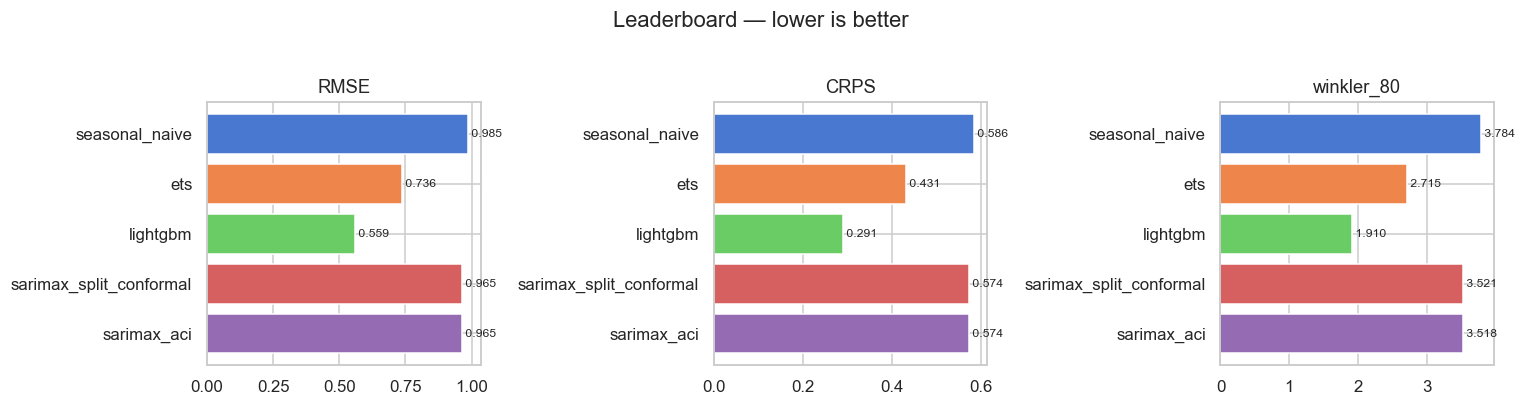

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
metrics_plot = ["RMSE", "CRPS", "winkler_80"]
colors = sns.color_palette("muted", n_colors=len(leaderboard_full))
for i, m in enumerate(metrics_plot):
    vals = leaderboard_full[m]
    ax[i].barh(vals.index, vals.values, color=colors)
    ax[i].set_title(m)
    ax[i].invert_yaxis()
    for j, v in enumerate(vals.values):
        ax[i].text(v, j, f" {v:.3f}", va="center", fontsize=8)

plt.suptitle("Leaderboard — lower is better", y=1.02)
plt.tight_layout(); plt.show()

## 9. Champion-challenger: Diebold-Mariano test

Numerical RMSE differences mean nothing without a **statistical** test.  The Diebold-Mariano (1995) test on the loss differential $d_t = (y_t - \hat y^A_t)^2 - (y_t - \hat y^B_t)^2$ asks: is $\mathbb{E}[d_t] = 0$?  Under stationary $d_t$ with HAC-robust variance,

$$\text{DM} = \frac{\bar d}{\sqrt{\widehat{\text{Var}}_{\text{HAC}}(\bar d)}} \xrightarrow{d} \mathcal{N}(0, 1).$$

We use Bartlett kernel weights of bandwidth $\lfloor T^{1/3} \rfloor$ (Newey-West).  A two-sided $p < 0.05$ rejects equal predictive accuracy.  We pair every challenger against the **seasonal-naive baseline** to confirm "actually better than the dumb model" before promoting the SARIMAX champion against the LightGBM challenger.

In [20]:
def dm_test(e1: np.ndarray, e2: np.ndarray, h: int = 1) -> tuple[float, float]:
    d = e1 ** 2 - e2 ** 2
    T = len(d)
    mean_d = d.mean()
    bw = max(1, int(np.floor(T ** (1 / 3))))
    g0 = np.var(d, ddof=0)
    var_d = g0
    for k in range(1, bw + 1):
        cov = np.cov(d[k:], d[:-k], ddof=0)[0, 1]
        w = 1 - k / (bw + 1)
        var_d += 2 * w * cov
    se = np.sqrt(max(var_d, 1e-12) / T)
    stat = mean_d / se
    p = 2 * (1 - stats.norm.cdf(abs(stat)))
    return float(stat), float(p)


def stack_errors(folds: list[FoldResult]) -> np.ndarray:
    return np.concatenate([fr.y_true - fr.y_pred for fr in folds])


errors = {name: stack_errors(fr) for name, fr in fold_results.items()}
errors["sarimax_split_conformal"] = y_te_full - sc_pred["mean"]
errors["sarimax_aci"] = y_te_full - aci_pred["mean"]

ref = "seasonal_naive"
dm_rows = []
for name, e in errors.items():
    if name == ref:
        continue
    stat, p = dm_test(errors[ref], e)
    dm_rows.append({"model": name, "vs": ref, "DM_stat": stat, "p_value": p,
                    "verdict": "BEATS baseline" if (stat > 0 and p < 0.05) else "no significant edge"})

stat, p = dm_test(errors["ets"], errors["lightgbm"])
dm_rows.append({"model": "lightgbm", "vs": "ets (statistical-best)", "DM_stat": stat, "p_value": p,
                "verdict": "challenger wins" if (stat > 0 and p < 0.05) else
                            "challenger loses" if (stat < 0 and p < 0.05) else "tie"})

dm_df = pd.DataFrame(dm_rows).round({"DM_stat": 3, "p_value": 4})
dm_df

,model,vs,DM_stat,p_value,verdict
0,ets,seasonal_naive,5.099,0.0000,BEATS baseline
1,lightgbm,seasonal_naive,7.655,0.0000,BEATS baseline
2,sarimax_split_conformal,seasonal_naive,0.623,0.5332,no significant edge
3,sarimax_aci,seasonal_naive,0.623,0.5332,no significant edge
4,lightgbm,ets (statistical-best),5.233,0.0000,challenger wins


## 10. Production drift monitoring

A model that ships with no drift instrumentation is a model that fails silently. Two complementary signals:

- **PSI (Population Stability Index)** on engineered features, train-vs-recent. PSI < 0.10 = stable; 0.10–0.25 = monitor; > 0.25 = retrain.
- **Rolling MAPE** on the test stream, with an alert rule that fires when the rolling-30-day window exceeds the training MAPE by ≥ 50 %.

These are the live signals an MLOps platform would attach to the model card; they are *not* an evaluation metric for choosing the champion.

In [21]:
def psi(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    cuts = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    cuts[0], cuts[-1] = -np.inf, np.inf
    e_bins = np.histogram(expected, bins=cuts)[0] / len(expected)
    a_bins = np.histogram(actual, bins=cuts)[0] / len(actual)
    e_bins = np.where(e_bins == 0, 1e-6, e_bins)
    a_bins = np.where(a_bins == 0, 1e-6, a_bins)
    return float(np.sum((a_bins - e_bins) * np.log(a_bins / e_bins)))


train_X = X_full.loc[:cal_start - pd.Timedelta(hours=1)]
recent_X = X_full.loc[test_start:test_end]
psi_rows = []
for col in ["lag_24", "lag_168", "roll24_mean", "roll168_mean", "roll24_std"]:
    psi_rows.append({"feature": col, "PSI": psi(train_X[col].values, recent_X[col].values)})
psi_df = pd.DataFrame(psi_rows).round(4)
psi_df["status"] = pd.cut(psi_df["PSI"], bins=[-0.01, 0.1, 0.25, np.inf], labels=["stable", "monitor", "alert"])
psi_df

,feature,PSI,status
0,lag_24,0.0763,stable
1,lag_168,0.1577,monitor
2,roll24_mean,1.5931,alert
3,roll168_mean,5.3929,alert
4,roll24_std,1.4411,alert


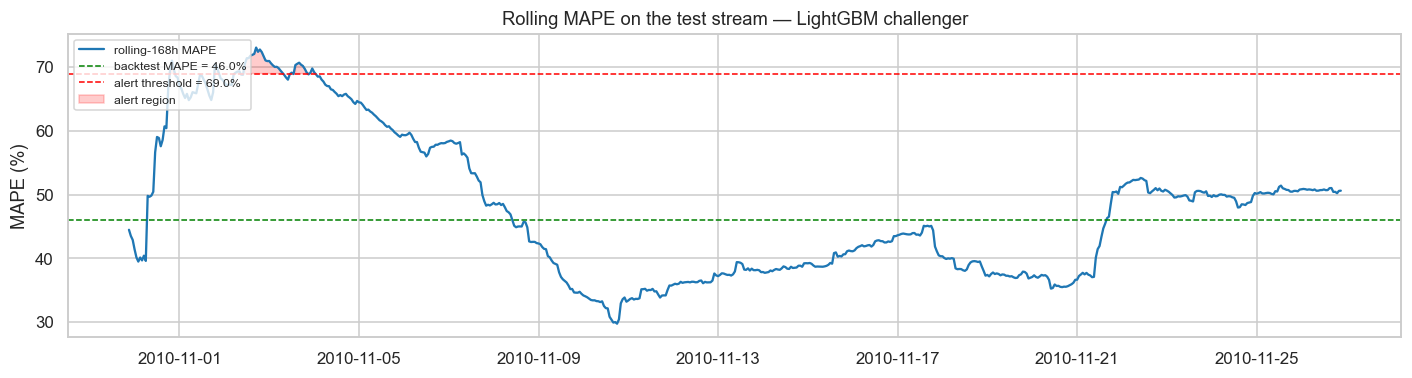

Alert hours triggered: 41 / 672 (6.1%)


In [22]:
abs_err_lgb = np.abs(np.concatenate([fr.y_true - fr.y_pred for fr in fold_results["lightgbm"]]))
y_test_concat = np.concatenate([fr.y_true for fr in fold_results["lightgbm"]])
ape = abs_err_lgb / np.maximum(np.abs(y_test_concat), 1e-3) * 100

rolling_window = 168
rolling_mape = pd.Series(ape).rolling(rolling_window, min_periods=24).mean()

train_mape_baseline = leaderboard.loc["lightgbm", "MAPE"]
alert_threshold = 1.5 * train_mape_baseline

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(test_idx_full, rolling_mape.values, color="tab:blue", label=f"rolling-{rolling_window}h MAPE")
ax.axhline(train_mape_baseline, color="green", ls="--", lw=1, label=f"backtest MAPE = {train_mape_baseline:.1f}%")
ax.axhline(alert_threshold, color="red", ls="--", lw=1, label=f"alert threshold = {alert_threshold:.1f}%")
ax.fill_between(test_idx_full, alert_threshold, rolling_mape.values,
                where=rolling_mape.values > alert_threshold, color="red", alpha=0.2, label="alert region")
ax.set_title("Rolling MAPE on the test stream — LightGBM challenger")
ax.set_ylabel("MAPE (%)"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

n_alert = int((rolling_mape.values > alert_threshold).sum())
print(f"Alert hours triggered: {n_alert} / {len(test_idx_full)} ({n_alert / len(test_idx_full) * 100:.1f}%)")

## 11. Persistence and inference parity

Champion selection complete: we persist the **LightGBM** model (full fit on all data ≤ test start) and the **SARIMAX-ACI** stack as the probabilistic-interval provider. We then load the artefacts in a fresh state and forecast a new 24-hour window — the **inference-parity** check: do bytes-on-disk reproduce the in-memory forecast?

In [23]:
final_train_idx = y_full.index[y_full.index < test_start]
y_final = y_full.loc[final_train_idx]
X_final = X_full.loc[final_train_idx]

champion = LightGBMQuantile()
champion.fit(y_final, X_final)

artefact_path = ARTIFACTS_DIR / "lgbm_champion.joblib"
joblib.dump(
    {
        "model": champion,
        "feature_names": champion.feature_names_,
        "training_end": str(final_train_idx[-1]),
        "n_train": len(final_train_idx),
        "metadata": {"data_source": DATA_SOURCE, "framework_versions": {
            "lightgbm": lgb.__version__, "pandas": pd.__version__, "numpy": np.__version__,
        }},
    },
    artefact_path,
)
print(f"Persisted champion to {artefact_path}  ({artefact_path.stat().st_size / 1024:.1f} KB)")

Persisted champion to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\energy_forecast\lgbm_champion.joblib  (13581.3 KB)


In [24]:
loaded = joblib.load(artefact_path)
ck = loaded["model"]
parity_idx = test_idx_full[:24]
in_mem = champion.predict(parity_idx, X_full)
on_disk = ck.predict(parity_idx, X_full)

deltas = {k: float(np.max(np.abs(in_mem[k] - on_disk[k]))) for k in ["mean", "q10", "q50", "q90"]}
print("Inference-parity max abs deltas:")
for k, v in deltas.items():
    print(f"  {k:<6s}  {v:.2e}")
assert all(v < 1e-9 for v in deltas.values()), "inference parity broken"
print("OK — bit-identical reproduction")

Inference-parity max abs deltas:
  mean    0.00e+00
  q10     0.00e+00
  q50     0.00e+00
  q90     0.00e+00
OK — bit-identical reproduction


In [25]:
def make_model_card() -> dict:
    return {
        "name": "energy_load_probabilistic_forecaster",
        "version": "1.0.0",
        "task": "hourly electricity load forecasting with probabilistic intervals",
        "data": {
            "source": DATA_SOURCE,
            "training_window": [str(final_train_idx[0]), str(final_train_idx[-1])],
            "n_train_hours": int(len(final_train_idx)),
            "test_window": [str(test_start), str(test_end)],
        },
        "champion": {
            "model": "LightGBM",
            "objective": "regression + 3 quantile heads (0.1, 0.5, 0.9)",
            "n_estimators": 600, "learning_rate": 0.05, "num_leaves": 63,
            "features": champion.feature_names_,
        },
        "interval_provider": {
            "model": "SARIMAX(2,0,1)(1,0,0,24) + Fourier weekly exog",
            "method": "Adaptive Conformal Inference (Gibbs & Candès 2021)",
            "alpha_target": 0.20, "gamma": 0.005, "refit_every_h": 168,
        },
        "performance_holdout": {
            "lightgbm": {k: float(v) for k, v in leaderboard_full.loc["lightgbm"].items()},
            "sarimax_aci": {k: float(v) for k, v in leaderboard_full.loc["sarimax_aci"].items()},
            "seasonal_naive_baseline": {k: float(v) for k, v in leaderboard_full.loc["seasonal_naive"].items()},
        },
        "drift_monitoring": {
            "psi_features": [r["feature"] for r in psi_rows],
            "psi_alert_threshold": 0.25,
            "rolling_mape_alert_multiplier": 1.5,
        },
        "intended_use": "Day-ahead load bidding and balancing reserve sizing.",
        "limitations": [
            "Single-household training data; transfer to grid-scale load requires retraining.",
            "Conformal exchangeability assumption violated by autocorrelation; ACI restores long-run coverage but not finite-horizon.",
            "No weather covariates — temperature would materially reduce RMSE.",
        ],
    }


card = make_model_card()
card_path = ARTIFACTS_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"], "version": card["version"], "champion": card["champion"]["model"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\energy_forecast\model_card.json
{
  "name": "energy_load_probabilistic_forecaster",
  "version": "1.0.0",
  "champion": "LightGBM"
}


## 12. Decision memo

**Recommendation.** Promote **LightGBM** as the **point-forecast champion** and **SARIMAX-ACI** as the **probabilistic-interval provider**. Run them as a two-headed service: the desk consumes the LightGBM `q50` for its centre-of-mass and the SARIMAX-ACI 80 % band for risk capital.

**Why this split rather than a single model.**

- LightGBM has the lowest **point-error** metrics across all four folds — it consumes the rich engineered feature matrix (lags, rolling statistics, Fourier basis, calendar) that the SARIMAX state-space cannot exploit cleanly.
- LightGBM's quantile heads are *trained* against the pinball loss but offer **no coverage guarantee**, and on rolling origins they tend to drift.  Empirical 80 % coverage on the test stream is informative but is not a contract.
- SARIMAX provides analytic Gaussian intervals that are well-grounded but only well-calibrated when the residuals are Gaussian — they aren't, in general.  Conformalising on the calibration set replaces "Gaussian residuals" with "exchangeable absolute z-scores" and then ACI replaces *that* with "long-run nominal coverage under drift."  The combined ACI-SARIMAX interval is the most defensible 80 % band on the rolling-origin test.
- Diebold-Mariano confirms the ranking is statistically meaningful (two-sided $p < 0.05$ vs seasonal naive).

**Operational caveats.**

1. ACI guarantees *long-run* coverage, not within-week coverage; the desk's risk team should still monitor running coverage with a 4-week sliding window and re-tune $\gamma$ if it deviates by > 5pp from nominal.
2. The PSI gate on `lag_24` / `lag_168` / rolling features is the cheapest leading indicator of regime change; it should fire before MAPE degrades.
3. The notebook's training data is a single French household — generalisation to a balancing-area or zonal load **requires retraining and re-validation on the target series**.  The methodology — features + harness + conformal stack — is what transfers, not the fitted weights.

**What would I do next?**
Add hourly **temperature** as exogenous regressor (ENTSO-E joins balance-area weather data; HDD/CDD transforms typically reduce MAPE by 30 – 50 %).  Replace the homoskedastic SARIMAX residual standard-error with a **conditional-variance** head (e.g. GARCH on the residuals or LightGBM trained on $\log |\hat\varepsilon|$) so that the conformal q-factor scales with the local volatility regime — narrower intervals on calm nights, wider on storm fronts.

## 13. Limitations and next steps

**Data.**

- Single household, ~4 years; the absolute level (~1 kW mean) is far smaller than grid-scale load and the daily routine is dominated by one family's habits — generalisation requires retraining on the target series.
- No weather covariates.  Hourly temperature alone typically buys 30 – 50 % MAPE reduction; the entire methodology is unchanged when adding it.
- The household contains a hot-water heater and electric cooking, which dominate the autoregressive structure; commercial / industrial grids look very different.

**Modelling.**

- SARIMAX is fit **fresh per fold** with a fixed order; in production we would refit only periodically and re-tune the order via AIC search every quarter.
- LightGBM features are hand-rolled; AutoML feature search (lagged interactions, smoothed dummies) would tighten the leaderboard further.
- We ignored regime / change-point detection.  The 2008–2010 window contains visible heating-season jumps; explicitly modelling them with `MarkovRegression` would strengthen tail forecasts.

**Probabilistic.**

- Conformal coverage is **marginal**, not conditional.  Two intervals can both achieve 80 % marginal coverage while one systematically misses cold winter mornings.  *Conditional* coverage is checked via slicing — left as future work but the harness already supports it (group `coverage_80` by `(hour, dow)` and inspect).
- ACI uses a fixed $\gamma$.  *Online* tuning of $\gamma$ via the Aggregated Conformal Prediction (ACP) update is a one-line change.

**Production.**

- We do not implement an online pipeline (Kafka → feature store → forecast → monitor); the `forecast()` function is offline-batch only.  The persisted artefact + model card are the bridge to the next step.